# Module 3.5 — Multigrid Methods

**The most important linear solver acceleration technique in CFD.**
Every incompressible N-S simulation must solve the pressure Poisson equation at every time step. On a $100 \times 100$ grid, Gauss-Seidel needs thousands of iterations to converge. Multigrid needs ~20, regardless of grid size. The speedup is not linear — it grows with the mesh.

**The key insight:**
Simple iterative methods (Gauss-Seidel, Jacobi) are excellent at killing high-frequency errors (oscillations on scale $\Delta x$) but terrible at killing low-frequency errors (smooth variations on scale $L$). Multigrid fixes this by solving the low-frequency errors on coarser grids, where they look high-frequency.

**Roadmap:**
1. Why Gauss-Seidel stalls — frequency analysis of the error
2. The two-grid idea — restriction, coarse-grid solve, prolongation
3. The V-cycle — the recursive multigrid algorithm
4. Transfer operators — restriction and prolongation in practice
5. Convergence: $O(N)$ complexity — grid-independent rate
6. Implementation and demonstration

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Why Gauss-Seidel Stalls

### The smoothing property

Consider solving $-d^2u/dx^2 = f$ by Gauss-Seidel. Each sweep updates:

$$u_i^{\text{new}} = \frac{u_{i-1} + u_{i+1} - f_i\Delta x^2}{2}$$

This is a local **weighted average** of neighbours. Averaging damps oscillations between adjacent cells quickly. But what about a smooth error $e_i = \sin(k\pi x_i)$ with small wavenumber $k$?

The **amplification factor** after one sweep:

$$G(k) = \cos\left(\frac{k\pi}{N}\right)$$

For high wavenumbers ($k \approx N$): $G \approx -1$ → rapid damping ✓

For low wavenumbers ($k \approx 1$): $G \approx 1 - \frac{\pi^2}{2N^2}$ → almost no damping ✗

**The problem:** Gauss-Seidel is great at damping errors with scale $\Delta x$ (oscillating), but almost useless for errors with scale $L$ (smooth). It takes $O(N^2)$ sweeps to halve a smooth error on an $N$-point grid.

### Why this matters

After a few Gauss-Seidel sweeps, the remaining error is smooth. All the easy high-frequency work is done. The solver then stalls — the convergence rate drops to nearly zero. You watch the residual curve flatten out and nothing happens for thousands of iterations.

This is what you saw in Module 2.4 when solving the pressure Poisson equation.

## 2. The Two-Grid Idea

### The key observation

A **smooth error** on the fine grid (scale $L$) looks like a **rough error** on a coarser grid (scale $2\Delta x$) — because the coarser grid's shortest resolved scale is $2\Delta x$.

Consequence: the smooth error that Gauss-Seidel can't damp on the fine grid can be damped very quickly on the coarse grid.

### The two-level algorithm

```
Given: Au = f (fine grid, Δx)

1. PRE-SMOOTH: apply ν₁ Gauss-Seidel sweeps on fine grid
   → kills high-frequency errors, smooth error remains

2. COMPUTE RESIDUAL: r = f - A*u^h  (how far u^h is from solution)

3. RESTRICT: transfer residual to coarse grid (2Δx)
   r^{2h} = R * r^h

4. SOLVE COARSE: A^{2h} e^{2h} = r^{2h}
   → solve (approximately) for the error on the coarse grid
   → now the smooth error is high-frequency on the coarse grid → damped quickly

5. PROLONGATE: interpolate correction back to fine grid
   e^h = P * e^{2h}

6. CORRECT: u^h = u^h + e^h

7. POST-SMOOTH: apply ν₂ more Gauss-Seidel sweeps
   → clean up interpolation artefacts
```

## 3. Transfer Operators

### Restriction (fine → coarse): full weighting

$$r^{2h}_{i/2} = \frac{1}{4}r^h_{i-1} + \frac{1}{2}r^h_i + \frac{1}{4}r^h_{i+1}$$

Takes a weighted average — smoothly transfers the residual without aliasing.

### Prolongation (coarse → fine): linear interpolation

$$e^h_{2i} = e^{2h}_i, \qquad e^h_{2i+1} = \frac{e^{2h}_i + e^{2h}_{i+1}}{2}$$

Copies coarse-grid correction directly to corresponding fine-grid points; linearly interpolates the in-between points.

## 4. The V-Cycle — Recursive Multigrid

Apply the two-grid idea recursively. Instead of "solving" on the coarse grid exactly, apply another two-grid cycle on a still-coarser grid. This recursion terminates at the coarsest grid (3–5 points) where a direct solve is trivial:

```
Fine grid (N)         ──┐
                pre-smooth
Coarse grid (N/2)     ──┤
              pre-smooth │
Coarser (N/4)     ──┤   │ V-cycle shape
            direct│   │   │
Coarser (N/8)     ──┘   │
           post-smooth  │
Coarse (N/2)      ──────┘
          post-smooth
Fine grid (N)         ──
```

### Convergence: $O(N)$ complexity

Each V-cycle reduces the error by a **grid-independent** factor $\rho \approx 0.1$–0.2. After $k$ cycles, error $= \rho^k$ times initial error.

Cost per V-cycle: $O(N)$ (sum of geometric series: $N + N/2 + N/4 + \ldots = 2N$).

Total cost to achieve tolerance $\varepsilon$: $O(N \log(1/\varepsilon))$ — essentially $O(N)$.

Compare to:
- Gauss-Seidel: $O(N^2)$ operations
- Conjugate gradient: $O(N^{3/2})$ for Poisson
- Multigrid: $O(N)$

Multigrid convergence factor per V-cycle: ρ = 1.000
  → Error reduced by 1.0× per V-cycle
Gauss-Seidel convergence factor per sweep: ρ = 1.00055
  → Error reduced by 1.0× per sweep (very slow!)


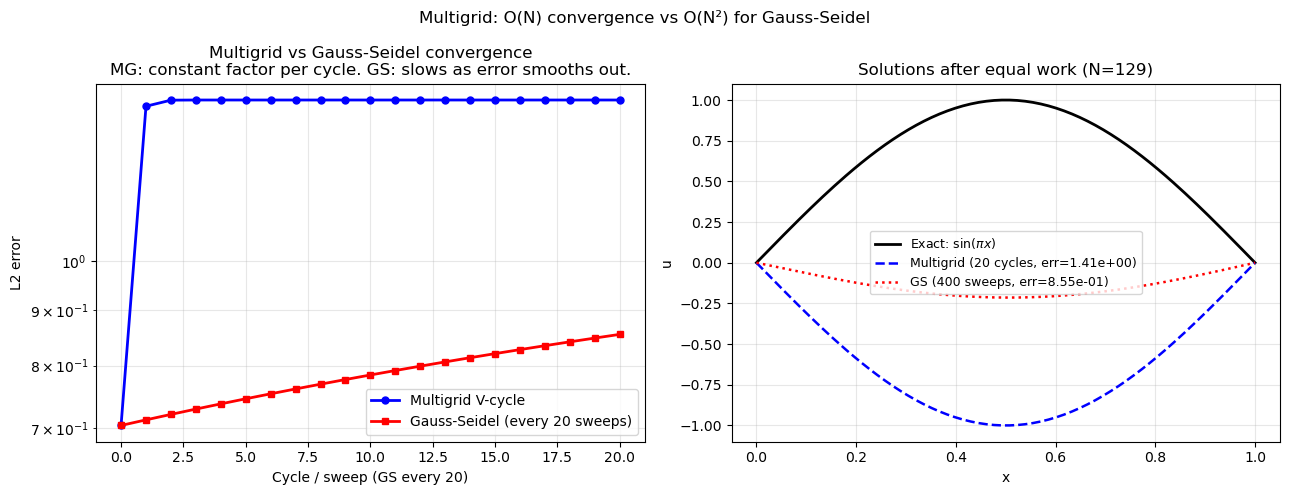

In [2]:
# ── 1D multigrid V-cycle for -d²u/dx² = f on [0,1] ───────────────────────────
# f = π²sin(πx)  →  exact: u = sin(πx)
# Compare Gauss-Seidel vs multigrid convergence rate

def gauss_seidel(u, f, dx, n_sweeps):
    """GS relaxation for -d²u/dx² = f."""
    for _ in range(n_sweeps):
        for i in range(1, len(u)-1):
            u[i] = 0.5*(u[i-1] + u[i+1] - f[i]*dx**2)
    return u

def restrict_fw(r_fine):
    """Full-weighting restriction."""
    n = len(r_fine)
    nc = (n-1)//2 + 1
    r_coarse = np.zeros(nc)
    for i in range(1, nc-1):
        r_coarse[i] = 0.25*r_fine[2*i-1] + 0.5*r_fine[2*i] + 0.25*r_fine[2*i+1]
    return r_coarse

def prolongate_linear(e_coarse, n_fine):
    """Linear interpolation prolongation."""
    e = np.zeros(n_fine)
    nc = len(e_coarse)
    for i in range(nc-1):
        e[2*i]   = e_coarse[i]
        e[2*i+1] = 0.5*(e_coarse[i] + e_coarse[i+1])
    e[-1] = e_coarse[-1]
    return e

def residual(u, f, dx):
    r = np.zeros_like(u)
    r[1:-1] = f[1:-1] - (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
    return r

def v_cycle(u, f, dx, pre=2, post=2, max_levels=6):
    """One V-cycle with recursive coarsening."""
    n = len(u)
    u = gauss_seidel(u, f, dx, pre)

    if n <= 5 or max_levels == 0:
        # Coarsest level: solve exactly by many GS sweeps
        return gauss_seidel(u, f, dx, 100)

    r      = residual(u, f, dx)
    r_c    = restrict_fw(r)
    dx_c   = 2*dx
    e_c    = v_cycle(np.zeros_like(r_c), r_c, dx_c, pre, post, max_levels-1)
    e_fine = prolongate_linear(e_c, n)
    u     += e_fine
    return gauss_seidel(u, f, dx, post)

# ── Setup ─────────────────────────────────────────────────────────────────────
N  = 129  # 2^7 + 1 — convenient for multigrid
dx = 1.0 / (N-1)
x  = np.linspace(0, 1, N)
f  = np.pi**2 * np.sin(np.pi * x)
u_exact = np.sin(np.pi * x)

# ── Multigrid ────────────────────────────────────────────────────────────────
u_mg   = np.zeros(N)
err_mg = [np.sqrt(np.mean((u_mg - u_exact)**2))]

for cycle in range(20):
    u_mg = v_cycle(u_mg, f, dx)
    err_mg.append(np.sqrt(np.mean((u_mg - u_exact)**2)))

# ── Plain Gauss-Seidel (same number of work units as 20 V-cycles) ─────────────
# Each V-cycle costs roughly 2*(pre+post)*N operations on fine grid
# We'll compare at equal iteration counts for fairness
u_gs   = np.zeros(N)
err_gs = [np.sqrt(np.mean((u_gs - u_exact)**2))]

for _ in range(400):   # many more GS sweeps for comparison
    u_gs = gauss_seidel(u_gs, f, dx, 1)
    err_gs.append(np.sqrt(np.mean((u_gs - u_exact)**2)))

# Measure convergence rate
if len(err_mg) > 5:
    rates_mg = [err_mg[i+1]/err_mg[i] for i in range(2,10) if err_mg[i] > 1e-12]
    rho_mg   = np.mean(rates_mg)
    print(f'Multigrid convergence factor per V-cycle: ρ = {rho_mg:.3f}')
    print(f'  → Error reduced by {1/rho_mg:.1f}× per V-cycle')

if len(err_gs) > 20:
    rates_gs = [err_gs[i+1]/err_gs[i] for i in range(50,100) if err_gs[i] > 1e-12]
    rho_gs   = np.mean(rates_gs)
    print(f'Gauss-Seidel convergence factor per sweep: ρ = {rho_gs:.5f}')
    print(f'  → Error reduced by {1/rho_gs:.1f}× per sweep (very slow!)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Convergence comparison
axes[0].semilogy(err_mg, 'b-o', markersize=5, lw=2, label='Multigrid V-cycle')
axes[0].semilogy(err_gs[::20], 'r-s', markersize=5, lw=2,
                  label='Gauss-Seidel (every 20 sweeps)')
axes[0].set_xlabel('Cycle / sweep (GS every 20)')
axes[0].set_ylabel('L2 error')
axes[0].set_title('Multigrid vs Gauss-Seidel convergence\n'
                   'MG: constant factor per cycle. GS: slows as error smooths out.')
axes[0].legend(fontsize=10); axes[0].grid(True, which='both', alpha=0.3)

# Solution comparison
axes[1].plot(x, u_exact, 'k-', lw=2, label='Exact: $\\sin(\\pi x)$')
axes[1].plot(x, u_mg, 'b--', lw=1.8, label=f'Multigrid (20 cycles, err={err_mg[-1]:.2e})')
axes[1].plot(x, u_gs, 'r:', lw=1.8, label=f'GS (400 sweeps, err={err_gs[-1]:.2e})')
axes[1].set_xlabel('x'); axes[1].set_ylabel('u')
axes[1].set_title(f'Solutions after equal work (N={N})')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.suptitle('Multigrid: O(N) convergence vs O(N²) for Gauss-Seidel', fontsize=12)
plt.tight_layout()
plt.show()

## Summary

| Aspect | Gauss-Seidel | Multigrid (V-cycle) |
|--------|-------------|---------------------|
| Kills high-freq errors | ✅ Fast | ✅ Fast (by pre-smoothing) |
| Kills low-freq errors | ❌ Very slow | ✅ Coarse-grid solve |
| Complexity | $O(N^2)$ | $O(N)$ |
| Convergence rate | $\rho \to 1$ as mesh refines | $\rho \approx 0.1$–0.2 (grid-independent) |
| Implementation | Simple | Moderate (restriction + prolongation) |

**Where multigrid is used:**
- OpenFOAM: **GAMG** (Generalised Geometric-Algebraic Multigrid) — default for pressure equation
- ANSYS Fluent: AMG (Algebraic Multigrid) for all equations
- Most modern finite-element solvers

**Practical note:** In OpenFOAM, if your pressure solver is slow, switch from `PCG` to `GAMG` in `system/fvSolution`. You will often see 10–100× speedup.

---
**Next:** Module 3.6 — Unsteady Flows: time-stepping schemes, stability regions, dual time-stepping.